# USGS dataretrieval Python Package `get_continuous()` Examples

This notebook provides examples of using the Python dataretrieval package to retrieve continuous (instantaneous, or "unit") values data for a United States Geological Survey (USGS) monitoring location. The dataretrieval package provides a collection of functions to get data from the USGS Water Data API and other online sources of hydrology and water quality data.

### Install the Package

Use the following code to install the package if it doesn't exist already within your Jupyter Python environment.

In [1]:
!pip install dataretrieval

Load the package so you can use it along with other packages used in this notebook.

In [2]:
from datetime import date

from IPython.display import display

import dataretrieval.waterdata as waterdata

### Basic Usage

The dataretrieval package has several functions that allow you to retrieve data from the USGS Water Data API. This example uses the `get_continuous()` function to retrieve continuous (instantaneous) streamflow data for a USGS monitoring location. The following arguments are supported:

* **monitoring_location_id** (string or iterable of strings): One or more unique monitoring location identifiers. An ID combines the agency code with the location number, separated by a hyphen (e.g. `USGS-10109000`).
* **parameter_code** (string or iterable of strings): One or more 5-digit USGS parameter codes identifying the constituent measured and its units (e.g. `00060` for discharge).
* **time** (string): The date or time interval for which to retrieve observations, given as an RFC 3339 date-time, a bounded or half-bounded interval (e.g. `2021-09-01/2021-09-30`), or an ISO 8601 duration. Continuous data are requested with `time`, and no more than three years of data may be requested per call. If `time` is omitted, the service returns the most recent year of measurements.

#### Example 1: Get unit value data for a specific parameter at a USGS monitoring location between a begin and end date

In [3]:
# Set the parameters needed for the web service call
siteID = "USGS-10109000"  # LOGAN RIVER ABOVE STATE DAM, NEAR LOGAN, UT
parameterCode = "00060"  # Discharge
startDate = "2021-09-01"
endDate = "2021-09-30"

# Get the data
discharge = waterdata.get_continuous(
    monitoring_location_id=siteID, parameter_code=parameterCode, time=f"{startDate}/{endDate}"
)
print("Retrieved " + str(len(discharge[0])) + " data values.")

Retrieving: continuous · 1 page · 2,785 rows


No API key detected — register for higher rate limits at https://api.waterdata.usgs.gov/signup/


Retrieved 2785 data values.


### Interpreting the Result

The `get_continuous()` function returns a tuple of two objects: a pandas data frame holding the observed values for the time period requested, and an associated metadata object. The data frame is flat, with a default integer index and one row per observation; the observation timestamps are stored in a tz-aware UTC `time` column rather than being used as the index.

Once you've got the data frame, there are several useful things you can do to explore the data.

In [4]:
# Display the data frame as a table
display(discharge[0])

,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id
0,92bf2ab5ea7d4c0080a619fbd5e360d9,USGS-10109000,00060,00011,2021-09-01 00:00:00+00:00,55.9,ft^3/s,Approved,None,2025-07-03 18:26:44.437050+00:00,c1d51022-849f-4c9c-a680-f5956bab8bc9
1,92bf2ab5ea7d4c0080a619fbd5e360d9,USGS-10109000,00060,00011,2021-09-01 00:15:00+00:00,55.9,ft^3/s,Approved,None,2025-07-03 18:26:44.437050+00:00,e283ab0d-0dc7-4c7c-b29a-11a990f47c5b
2,92bf2ab5ea7d4c0080a619fbd5e360d9,USGS-10109000,00060,00011,2021-09-01 00:30:00+00:00,55.9,ft^3/s,Approved,None,2025-07-03 18:26:44.437050+00:00,33a3d549-51e2-4b47-b420-b607fd0b3497
3,92bf2ab5ea7d4c0080a619fbd5e360d9,USGS-10109000,00060,00011,2021-09-01 00:45:00+00:00,55.9,ft^3/s,Approved,None,2025-07-03 18:26:44.437050+00:00,f3fb4785-5109-434e-8625-c59f5554cd18
4,92bf2ab5ea7d4c0080a619fbd5e360d9,USGS-10109000,00060,00011,2021-09-01 01:00:00+00:00,55.9,ft^3/s,Approved,None,2025-07-03 18:26:44.437050+00:00,c91ea645-9a58-4265-b0e0-d628dd4000ab
...,...,...,...,...,...,...,...,...,...,...,...
2780,92bf2ab5ea7d4c0080a619fbd5e360d9,USGS-10109000,00060,00011,2021-09-29 23:00:00+00:00,53.2,ft^3/s,Approved,None,2025-07-03 18:26:44.437050+00:00,7c019805-71a2-4f6e-85c6-901274cb124e
2781,92bf2ab5ea7d4c0080a619fbd5e360d9,USGS-10109000,00060,00011,2021-09-29 23:15:00+00:00,53.2,ft^3/s,Approved,None,2025-07-03 18:26:44.437050+00:00,20f92c76-913e-40e0-b1e8-7ad590503c22
2782,92bf2ab5ea7d4c0080a619fbd5e360d9,USGS-10109000,00060,00011,2021-09-29 23:30:00+00:00,53.2,ft^3/s,Approved,None,2025-07-03 18:26:44.437050+00:00,987b74ac-c2d1-44ce-aa92-06184f0cc29b
2783,92bf2ab5ea7d4c0080a619fbd5e360d9,USGS-10109000,00060,00011,2021-09-29 23:45:00+00:00,53.2,ft^3/s,Approved,None,2025-07-03 18:26:44.437050+00:00,a5540ab1-47db-4bdc-947f-e4f5a7ba1884


Show the data types of the columns in the resulting data frame.

In [5]:
print(discharge[0].dtypes)

time_series_id                            str
monitoring_location_id                    str
parameter_code                            str
statistic_id                              str
time                      datetime64[us, UTC]
value                                 float64
unit_of_measure                           str
approval_status                           str
qualifier                              object
last_modified             datetime64[us, UTC]
continuous_id                             str
dtype: object


Get summary statistics for the streamflow values.

In [6]:
discharge[0].describe()

,value
count,2785.000000
mean,51.565278
std,4.184643
min,24.400000
25%,49.100000
50%,53.200000
75%,54.500000
max,76.400000


Make a quick time series plot.

Text(0, 0.5, 'Streamflow (cfs)')

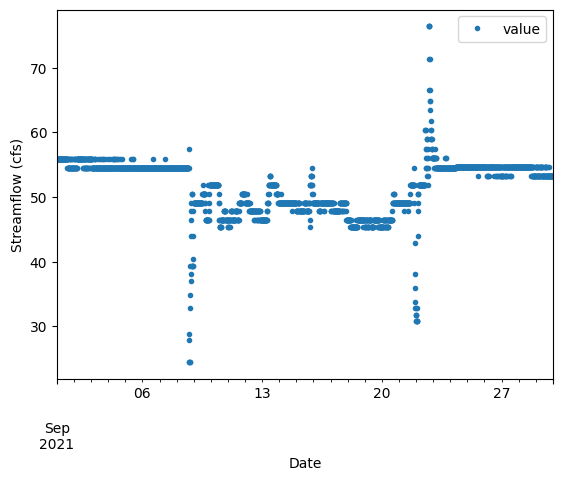

In [7]:
ax = discharge[0].plot(x="time", y="value", style=".")
ax.set_xlabel("Date")
ax.set_ylabel("Streamflow (cfs)")

The other part of the result returned from the `get_continuous()` function is a metadata object that contains information about the query that was executed to return the data. For example, you can access the URL that was assembled to retrieve the requested data from the USGS Water Data API.

In [8]:
print("The query URL used to retrieve the data from the Water Data API was: " + discharge[1].url)

The query URL used to retrieve the data from the Water Data API was: https://api.waterdata.usgs.gov/ogcapi/v0/collections/continuous/items?monitoring_location_id=USGS-10109000&parameter_code=00060&time=2021-09-01%2F2021-09-30&skipGeometry=false&limit=50000


### Additional Examples

#### Example 2: Get unit values for an individual monitoring location and parameter between a start and end date.

NOTE: By default, start and end date are evaluated as local time, and the result is returned with the timestamps in the local time of the monitoring location.

In [9]:
site_id = "USGS-05114000"
startDate = "2014-10-10"
endDate = "2014-10-10"

discharge2 = waterdata.get_continuous(
    monitoring_location_id=site_id, parameter_code=parameterCode, time=f"{startDate}/{endDate}"
)
print("Retrieved " + str(len(discharge2[0])) + " data values.")
display(discharge2[0])

Retrieving: continuous · 1 page · 1 rows

Retrieved 1 data values.


,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id
0,987c2d767a5a4981acffd51fa253b63b,USGS-05114000,00060,00011,2014-10-10 00:00:00+00:00,481,ft^3/s,Approved,None,2025-09-01 12:22:04.139884+00:00,bde6e74b-0d6c-4f13-bbc8-8ed1ff336fc6


#### Example 3: Get unit values for an individual monitoring location for today

In [10]:
today = str(date.today())
discharge_today = waterdata.get_continuous(
    monitoring_location_id=site_id, parameter_code=parameterCode, time=f"{today}/{today}"
)
print("Retrieved " + str(len(discharge_today[0])) + " data values.")
display(discharge_today[0])

Retrieving: continuous · 1 page · 1 rows

Retrieved 1 data values.


,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id
0,987c2d767a5a4981acffd51fa253b63b,USGS-05114000,00060,00011,2026-06-01 00:00:00+00:00,98.8,ft^3/s,Provisional,None,2026-06-01 00:14:29.299038+00:00,91f86cf8-d524-403d-8bb6-0234eb2e00b3


#### Example 4: Retrieve data using UTC times

NOTE: Adding 'Z' to the input time parameters indicates that they are in UTC rather than local time. The time stamps associated with the data returned are still in the local time of the USGS monitoring location.

In [11]:
discharge_UTC = waterdata.get_continuous(
    monitoring_location_id=site_id,
    parameter_code=parameterCode,
    time="2014-10-10T00:00Z/2014-10-10T23:59Z",
)
print("Retrieved " + str(len(discharge_UTC[0])) + " data values.")
display(discharge_UTC[0])

Retrieving: continuous · 1 page · 96 rows

Retrieved 96 data values.


,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id
0,987c2d767a5a4981acffd51fa253b63b,USGS-05114000,00060,00011,2014-10-10 00:00:00+00:00,481,ft^3/s,Approved,None,2025-09-01 12:22:04.139884+00:00,bde6e74b-0d6c-4f13-bbc8-8ed1ff336fc6
1,987c2d767a5a4981acffd51fa253b63b,USGS-05114000,00060,00011,2014-10-10 00:15:00+00:00,481,ft^3/s,Approved,None,2025-09-01 12:22:04.139884+00:00,ac396e6b-d731-419a-9f7f-807b5e3cec73
2,987c2d767a5a4981acffd51fa253b63b,USGS-05114000,00060,00011,2014-10-10 00:30:00+00:00,480,ft^3/s,Approved,None,2025-09-01 12:22:04.139884+00:00,889af5a8-850c-46e0-afb3-e472991a7001
3,987c2d767a5a4981acffd51fa253b63b,USGS-05114000,00060,00011,2014-10-10 00:45:00+00:00,480,ft^3/s,Approved,None,2025-09-01 12:22:04.139884+00:00,ac1198c8-0857-43e1-998b-f1e7382429eb
4,987c2d767a5a4981acffd51fa253b63b,USGS-05114000,00060,00011,2014-10-10 01:00:00+00:00,480,ft^3/s,Approved,None,2025-09-01 12:22:04.139884+00:00,e787d026-fce2-4f1f-a253-d2e0af849e06
...,...,...,...,...,...,...,...,...,...,...,...
91,987c2d767a5a4981acffd51fa253b63b,USGS-05114000,00060,00011,2014-10-10 22:45:00+00:00,478,ft^3/s,Approved,None,2025-09-01 12:22:04.139884+00:00,0922c174-5d17-4751-88a6-63455b407486
92,987c2d767a5a4981acffd51fa253b63b,USGS-05114000,00060,00011,2014-10-10 23:00:00+00:00,478,ft^3/s,Approved,None,2025-09-01 12:22:04.139884+00:00,2470636f-3b9d-4cda-968b-dabd01b1a844
93,987c2d767a5a4981acffd51fa253b63b,USGS-05114000,00060,00011,2014-10-10 23:15:00+00:00,478,ft^3/s,Approved,None,2025-09-01 12:22:04.139884+00:00,f6b7c7c7-058b-4264-95a1-3683c095d92e
94,987c2d767a5a4981acffd51fa253b63b,USGS-05114000,00060,00011,2014-10-10 23:30:00+00:00,478,ft^3/s,Approved,None,2025-09-01 12:22:04.139884+00:00,c293157c-bd5b-4685-bb06-4a7597ca2932


#### Example 5: Get unit values for two monitoring locations, for a single parameter, between a start and end date

In [12]:
discharge_multisite = waterdata.get_continuous(
    monitoring_location_id=["USGS-04024430", "USGS-04024000"],
    parameter_code=parameterCode,
    time="2013-10-01/2013-10-01",
)
print("Retrieved " + str(len(discharge_multisite[0])) + " data values.")
display(discharge_multisite[0])

Retrieving: continuous · 1 page · 2 rows

Retrieved 2 data values.


,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id
0,38100b0bedd043a8b2c8dfb7cde830d3,USGS-04024000,00060,00011,2013-10-01 00:00:00+00:00,567.0,ft^3/s,Approved,None,2025-08-27 16:02:26.026729+00:00,86d87afb-0c3c-4e64-b759-4a1e7ae3d374
1,24dfcb980fb24aa1b44e129b67b11a73,USGS-04024430,00060,00011,2013-10-01 00:00:00+00:00,63.0,ft^3/s,Approved,None,2025-08-21 19:19:27.898360+00:00,50e6a614-b358-4b01-83e0-8c7ac21a8730


The following example requests the same two-location data as the previous example.

In [13]:
discharge_multisite = waterdata.get_continuous(
    monitoring_location_id=["USGS-04024430", "USGS-04024000"],
    parameter_code=parameterCode,
    time="2013-10-01/2013-10-01",
    
)
print("Retrieved " + str(len(discharge_multisite[0])) + " data values.")
display(discharge_multisite[0])

Retrieving: continuous · 1 page · 2 rows

Retrieved 2 data values.


,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id
0,38100b0bedd043a8b2c8dfb7cde830d3,USGS-04024000,00060,00011,2013-10-01 00:00:00+00:00,567.0,ft^3/s,Approved,None,2025-08-27 16:02:26.026729+00:00,86d87afb-0c3c-4e64-b759-4a1e7ae3d374
1,24dfcb980fb24aa1b44e129b67b11a73,USGS-04024430,00060,00011,2013-10-01 00:00:00+00:00,63.0,ft^3/s,Approved,None,2025-08-21 19:19:27.898360+00:00,50e6a614-b358-4b01-83e0-8c7ac21a8730
